# Internship Documents Parsing

To reduce API costs and enable local document parsing, we explored the use of pretrained Vision-Language Models (VLMs) as a potential solution for extracting structured information from documents such as invoices.

## What's a VLM ?

A VLM - Vision Language Models are AI models that can understand both text and image. It works by aligning the visual and textual representations of inputs using three major components :
- 1 - Visual encoder: A vision transformer that converts the input image into a sequence of visual embeddings.
- 2 - Text encoder : A transformer based encoder which converts the input text into language embeddings.
- 3 - Multimodal Fusion Model : where the two modalities meet through one of the three main ways:
  - Early fusion: combines visual and text embeddings at the beginning and train a single transformer to process both.
  - Late fusion: Encode each input type separately and align them using similarity losses.
  - Cross-attention fusion: using attention mechanisms where tokes from either modality attend to the other.

> What exactly is a VLM (Vision-Language Model)? - From Vizuara AI in Medium

## Exploring solutions:

Initial experiments ( using one document for now ) with general-purpose VLMs, particularly Qwen2-VL-7B, showed that large VLMs can achieve very good extraction results when provided with an appropriate prompt. However, these models have a relatively high computational cost at inference time due to their size and general-purpose architecture. In addition, relying on prompts for each extraction task can make the solution less efficient than a model specifically adapted to the targeted document types and output format.

Therefore, several approaches are being considered to obtain a more efficient solution:

* **Knowledge distillation:** use a larger VLM such as Qwen2-VL-7B as a teacher model to generate annotations or reference outputs for our document dataset, then use these results to fine-tune a smaller model as the student. Techniques such as LoRA/QLoRA can be used to reduce the cost of fine-tuning. The objective is to retain as much as possible of the larger model's extraction performance while reducing inference cost. Public fine-tuning results on receipt/invoice-style extraction show this approach primarily fixes output *reliability* (valid JSON rate close to 100% after fine-tuning, vs. a low rate for the base model prompted zero-shot), in addition to improving field-level accuracy.

* **OCR-free document parsing:** investigate models specifically pretrained for document understanding rather than general-purpose chat, which start closer to our target distribution and are meaningfully cheaper to run than a 7B generalist. Candidates to benchmark:
  * **Donut** (~200M encoder-decoder) — one of the earliest and lightest OCR-free document models; trained end-to-end to map a document image directly to structured output tokens (e.g. JSON), no OCR engine or bounding boxes involved. Good low-cost baseline given its small size, though older and less capable on complex/noisy layouts than the newer models below.
  * **dots.ocr** (~1.7B) — unifies layout detection and content recognition in a single model
  * **PaddleOCR-VL** (~0.9B, *not* the classic PaddleOCR engine — see note below) — strong on complex layouts/tables, wide language coverage
  * **DeepSeek-OCR** (~3B MoE, ~570M active) — uses "context optical compression" to represent document content with far fewer vision tokens than an equivalent text-token representation, directly lowering inference cost
  * **Granite-Docling** (~258M) — integrates with a document-parsing pipeline, outputs Markdown/JSON/HTML natively

  Fine-tuning one of these on our documents and target JSON schema could provide a more specialized and efficient solution than adapting a general-purpose 7B model.

* **OCR + language model (two-stage):** separate the document parsing process into two stages — an OCR/layout model extracts text and spatial information, then a second model converts it into the required structured JSON. Candidates for the second stage:
  - **LayoutLM / LayoutLMv3** — jointly encodes the OCR-extracted text tokens with their 2D bounding-box positions (and optionally image patches) to classify each token by field. Requires an external OCR engine (e.g. classic PaddleOCR, Tesseract) to supply text + boxes as input. Extraction is done via token classification rather than free-form generation, so a separate formatting step is needed to turn its tagged output into our target JSON schema — it isn't a drop-in generative JSON producer like the OCR-free candidates.
  - a lightweight text-only LLM taking OCR text as input and generating the JSON directly (simpler to wire up than LayoutLM, but loses layout/spatial information unless the OCR output includes and the prompt encodes bounding boxes).

  This can reduce the compute cost of the second stage since it doesn't need a vision tower.

* **Constrained / schema-guided decoding (cross-cutting, applies to any of the above):** since our output schema is fixed and known in advance, inference-time JSON-schema-constrained decoding (e.g. via vLLM + guided/grammar-based decoding) can guarantee schema-valid output by construction, eliminating JSON-repair post-processing and reducing generated-token count (and therefore latency/cost) regardless of which model we pick. This should be adopted independently of the distillation/architecture decision.

We also need to take into consideration document classification: if each incoming document isn't classified before extraction, a separate classifier adds its own inference cost. An alternative worth testing is including the document type as a field in the fine-tuned model's own output schema, letting one model handle classification and extraction jointly rather than paying for two inference calls.

## Cost target

Our ceiling is around $0.10 per document, based on current Mindee subscription costs. Our system needs to match Mindee's coverage (document types, fields, accuracy) at or below this cost to be a successful tradeoff. To make this concrete, cost per document for a self-hosted model should be estimated as:

```
$/document ≈ (GPU cost per hour) / (documents processed per hour at target batch size)
```

This depends on model size, quantization, average image resolution/token count, and batching, so it should be measured empirically once a candidate model is fine-tuned rather than assumed. This will let us directly compare each candidate architecture against the $0.10 ceiling.

## Next steps / evaluation plan

* Build a labeled benchmark set of invoices (auto-labeled by the 7B teacher model, spot-corrected manually) with held-out test documents.
* Benchmark candidates (fine-tuned small Qwen VLM, fine-tuned OCR-native model, two-stage OCR+LLM) on: field-level exact match / F1 against ground truth, end-to-end latency, and measured $/document.
* Apply schema-constrained decoding uniformly across candidates so comparisons isolate model quality rather than JSON-formatting failures.

## Experiment ran on a mindee type invoice using Qwen2-VL-7B


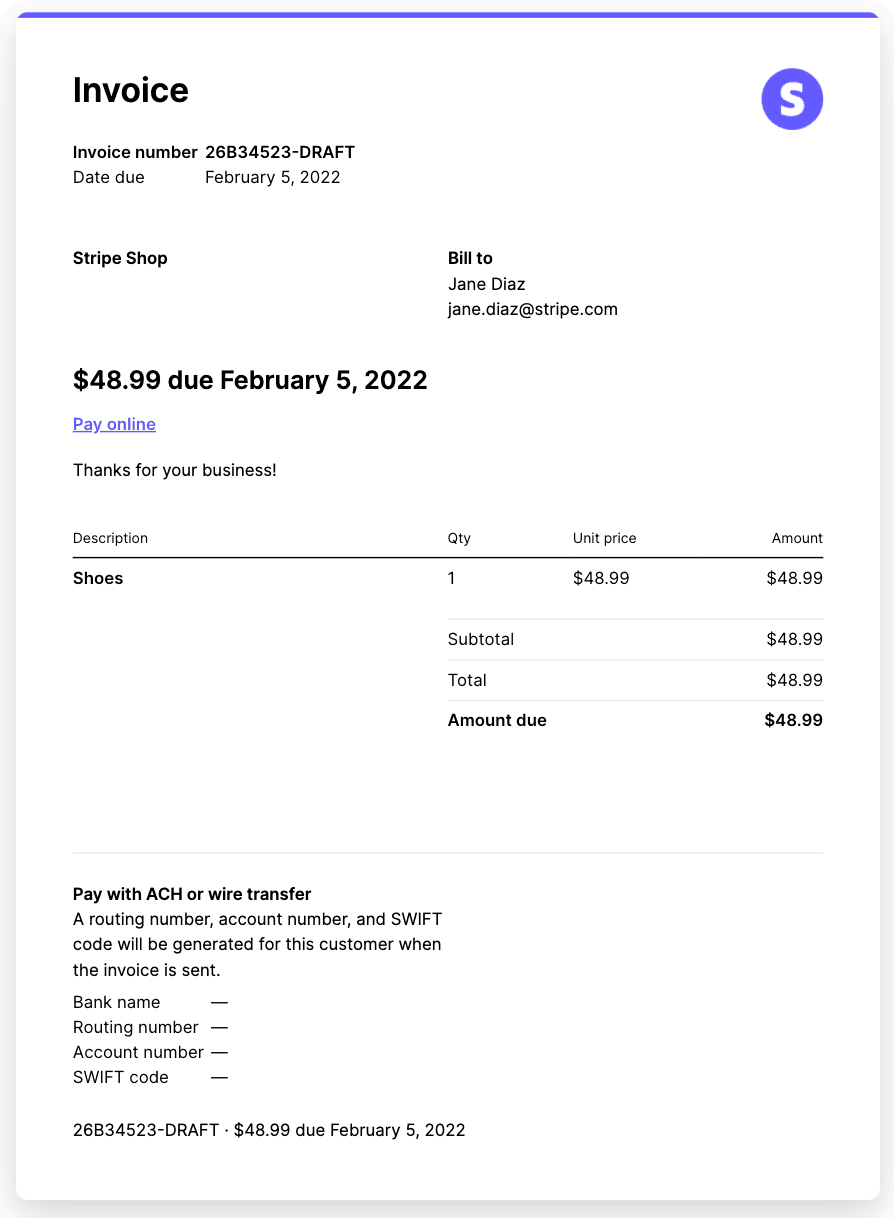

In [ ]:
!pip install -U transformers accelerate bitsandbytes qwen-vl-utils
!pip install -U optimum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 9.9 MB/s eta 0:00:00


In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")

CUDA: True
GPU: Tesla T4
VRAM: 14.56 GB


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 1_us_invoice.png to 1_us_invoice.png


In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

model_id = "Qwen/Qwen2-VL-7B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(
    model_id,
    min_pixels=256 * 28 * 28,
    max_pixels=1280 * 28 * 28,
)

print("Model loaded!")

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.5k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/730 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Model loaded!


In [ ]:
import json

# Kept the same invoice_schema as Mindee
invoice_schema = {
    "invoice_number": None,
    "invoice_date": None,
    "due_date": None,

    "supplier": {
        "name": None,
        "address": None,
        "email": None,
        "phone": None
    },

    "customer": {
        "name": None,
        "address": None,
        "email": None,
        "phone": None
    },

    "currency": None,

    "items": [
        {
            "description": None,
            "quantity": None,
            "unit_price": None,
            "amount": None
        }
    ],

    "subtotal": None,
    "tax": None,
    "total": None,
    "amount_due": None
}

print(json.dumps(invoice_schema, indent=2))

{
  "invoice_number": null,
  "invoice_date": null,
  "due_date": null,
  "supplier": {
    "name": null,
    "address": null,
    "email": null,
    "phone": null
  },
  "customer": {
    "name": null,
    "address": null,
    "email": null,
    "phone": null
  },
  "currency": null,
  "items": [
    {
      "description": null,
      "quantity": null,
      "unit_price": null,
      "amount": null
    }
  ],
  "subtotal": null,
  "tax": null,
  "total": null,
  "amount_due": null
}


In [ ]:
image_path = "1_us_invoice.png"

prompt = f"""
You are an invoice information extraction system.

Analyze the invoice image carefully and extract the information into the JSON schema below.

Return ONLY valid JSON.
Do not return Markdown.
Do not explain your answer.

Rules:
- Use null when information is not present or cannot be determined.
- Do not invent information.
- Preserve invoice values accurately.
- Extract every line item.
- quantity must be a number.
- unit_price, amount, subtotal, tax, total, and amount_due must be numbers when present.
- currency should be the currency code such as USD, EUR, or MAD.
- Dates should use YYYY-MM-DD when the date can be determined.
- Distinguish the supplier from the customer.
- The "amount_due" field means the amount currently due.

JSON schema:

{json.dumps(invoice_schema, indent=2)}
"""

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image_path,
            },
            {
                "type": "text",
                "text": prompt,
            },
        ],
    }
]

In [ ]:
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

from qwen_vl_utils import process_vision_info

image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)

inputs = inputs.to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=1000,
        temperature=0.0,
        do_sample=False,
    )

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print(output_text)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


```json
{
  "invoice_number": "26B34523-DRAFT",
  "invoice_date": null,
  "due_date": "2022-02-05",
  "supplier": {
    "name": "Stripe Shop",
    "address": null,
    "email": null,
    "phone": null
  },
  "customer": {
    "name": "Jane Diaz",
    "address": null,
    "email": "jane.diaz@stripe.com",
    "phone": null
  },
  "currency": "USD",
  "items": [
    {
      "description": "Shoes",
      "quantity": 1,
      "unit_price": 48.99,
      "amount": 48.99
    }
  ],
  "subtotal": 48.99,
  "tax": null,
  "total": 48.99,
  "amount_due": 48.99
}
```


## Data Collection

### 1. Invoices

To begin the training process, it is necessary to construct a dataset that adequately represents the target problem. We currently have access to a private dataset of real-world invoices. However, these invoices are generated by the same invoicing software and consequently share a relatively similar layout. While this homogeneity can be advantageous for achieving high accuracy on the expected inference data, it also raises concerns about the model's ability to handle variations that may occur in real-world conditions.

The main question is therefore whether the model should be trained exclusively on the private dataset, allowing it to become highly specialized to the target invoice patterns, or whether it should be combined with public invoice datasets to introduce greater layout diversity and improve generalization.

This question can be reframed as a trade-off between **specialization and robustness**. A model trained primarily on the private dataset can exploit stable structural characteristics of the target invoices, such as the position of specific fields, the organization of the header, or the structure of the item table. Since these characteristics are expected to remain relatively consistent during inference, learning them is not necessarily undesirable. In fact, this specialization can contribute to higher extraction accuracy and potentially reduce the computational requirements of the final system.

However, excessive specialization can lead to brittleness. A model may become overly dependent on exact spatial positions or visual characteristics and consequently perform poorly when faced with relatively small changes. Examples include modifications to the invoicing software, changes in formatting, missing optional fields, additional line items, multi-page invoices, or degraded document quality. The objective is therefore not to completely avoid specialization, but rather to prevent the model from becoming dependent on characteristics that are not guaranteed to remain stable.

#### Proposed Training Strategy

To achieve this balance, we propose a **two-stage training strategy** combining public and private data.

During the first stage, the model will be exposed to a diverse collection of invoices in order to develop general invoice understanding. For this purpose, we selected the **FATURA dataset**, which contains approximately **10,000 JPG invoice images and 30,000 JSON annotation files**. The diversity of this dataset provides exposure to different invoice structures and layouts, allowing the model to learn more general relationships between the visual structure of an invoice and the information it contains.

The objective of this stage is not to build a model capable of handling every possible invoice format with equal performance. Instead, the public dataset serves as a way to establish a general invoice representation and reduce excessive dependence on the characteristics of our private dataset.

In the second stage, the resulting model will undergo a shorter and more focused fine-tuning process using the private dataset. This stage will adapt the general invoice understanding acquired previously to the specific requirements of our production environment, including its layouts, field structure, formatting conventions, and annotation schema. Because the private data is much closer to the expected inference distribution, this stage is expected to provide the highest impact on final production accuracy.

#### Data Augmentation

Dataset diversity alone may not be sufficient to prevent overfitting. Even within the public dataset, a model could learn visual characteristics that are specific to the training images. Similarly, the private dataset may contain limited variation in document appearance despite containing different invoice values.

For this reason, both datasets will be augmented using **Augraphy**. The augmentation process will introduce realistic document variations such as rotation, skew, blur, noise, compression artifacts, shadows, and other scanning or image-quality degradations. These transformations are intended to simulate variations that could occur during real inference while preserving the underlying information of the document.

Content variability will also be considered. The dataset should contain sufficient variation in values such as supplier names, dates, invoice numbers, amounts, currencies, VAT rates, and numbers of line items. This is important to ensure that the model learns to extract information from the document rather than memorizing recurring values or fixed patterns.

#### Evaluation Strategy

The effectiveness of this approach will ultimately be determined experimentally. In addition to evaluating the model on a test set following the same distribution as the private data, we will evaluate its performance on documents with layouts or visual characteristics that were not present during training.

This will allow us to measure two complementary properties: **accuracy on the target production distribution** and **robustness to distribution shifts**. Different proportions of public and private data can also be evaluated to determine whether additional layout diversity provides a significant benefit or whether it mainly introduces irrelevant variation.

The expected outcome is therefore a model that remains highly specialized to the documents encountered in production while retaining sufficient robustness to realistic variations. Rather than maximizing generalization to arbitrary invoice layouts, the objective is to achieve the best balance between **inference accuracy, robustness, and computational efficiency** for the actual deployment scenario.

### 2. Paystubs

For paystubs, we currently have three different document templates in our private production dataset. This makes the problem different from invoices: rather than primarily addressing generalization across a large number of unknown layouts, the objective is to achieve robust performance across a **limited set of known templates** while preserving the model's ability to adapt to future ones.

Since paystubs and invoices share several characteristics as structured business documents, we will investigate **multi-domain transfer learning** by using the best pretrained invoice model as the starting point for paystub extraction, rather than training a new model from scratch.

This approach is supported by previous research on information extraction from form-like documents.
> In *Data-Efficient Information Extraction from Form-Like Documents*, the authors show that multidomain transfer learning can improve data-efficient generalization when transferring from English invoices to structurally different paystubs. Their experiments demonstrated improvements over both training from scratch and conventional transfer-learning baselines, particularly when only a limited number of labeled documents were available.

Therefore, the pretrained invoice model will serve as the initialization for the paystub model, after which it will be fine-tuned on the three available production templates. This approach allows the model to retain representations learned from the invoice domain while adapting them to the specific structure and fields of paystubs.

The three templates will be explicitly represented during training and evaluation to ensure that the model does not become excessively biased toward one particular layout. Their relative importance can also be weighted according to their expected frequency in production rather than assuming that all templates are equally represented.

Finally, the architecture should remain adaptable to future changes in the production distribution. If a fourth paystub template is introduced, an **adapter-based or parameter-efficient fine-tuning approach** could allow the new template to be incorporated without retraining the entire model from scratch. This would provide a more scalable approach to maintaining the extraction system as new document templates are introduced.
